In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
products = pd.read_csv("../data/raw/products.csv")
orders = pd.read_csv("../data/raw/orders.csv")
returns = pd.read_csv("../data/raw/returns.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [3]:
sales_product = orders.merge(
    products,
    on="product_id",
    how="left"
)

print("Sales + Product dataset created successfully!")
print("Shape:", sales_product.shape)

sales_product.head()

Sales + Product dataset created successfully!
Shape: (60000, 14)


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount_percent,payment_method,order_status,product_name,category,sub_category,cost_price,selling_price
0,O100000,C101341,P1280,2025-06-28,2,6428.58,10,UPI,Delivered,Water Bottle 281,Home & Kitchen,Premium,3458.70,6428.58
1,O100001,C100981,P1252,2025-07-30,4,1455.88,0,UPI,Delivered,Sneakers 253,Fashion,Standard,814.29,1455.88
2,O100002,C109509,P1371,2025-06-29,4,3225.49,10,Credit Card,Delivered,Protein Shaker 372,Fitness,Basic,2147.13,3225.49
3,O100003,C101497,P1421,2025-03-30,2,3737.93,10,UPI,Delivered,Wireless Headphones 422,Electronics,Premium,1861.18,3737.93
4,O100004,C101120,P1302,2025-09-13,4,3921.72,20,Debit Card,Delivered,Wireless Headphones 303,Electronics,Premium,2460.58,3921.72


In [4]:
# Gross revenue before discount
sales_product["gross_revenue"] = (
    sales_product["quantity"] *
    sales_product["unit_price"]
)

# Discount amount
sales_product["discount_amount"] = (
    sales_product["gross_revenue"] *
    sales_product["discount_percent"] / 100
)

# Net revenue after discount
sales_product["net_revenue"] = (
    sales_product["gross_revenue"] -
    sales_product["discount_amount"]
)

# Total product cost
sales_product["total_cost"] = (
    sales_product["quantity"] *
    sales_product["cost_price"]
)

# Gross profit
sales_product["gross_profit"] = (
    sales_product["net_revenue"] -
    sales_product["total_cost"]
)

# Profit margin percentage
sales_product["profit_margin"] = (
    sales_product["gross_profit"] /
    sales_product["net_revenue"]
) * 100

print("Product financial metrics calculated successfully!")

sales_product[
    [
        "product_id",
        "product_name",
        "quantity",
        "gross_revenue",
        "discount_amount",
        "net_revenue",
        "total_cost",
        "gross_profit",
        "profit_margin"
    ]
].head()

Product financial metrics calculated successfully!


,product_id,product_name,quantity,gross_revenue,discount_amount,net_revenue,total_cost,gross_profit,profit_margin
0,P1280,Water Bottle 281,2,12857.16,1285.716,11571.444,6917.40,4654.044,40.220080
1,P1252,Sneakers 253,4,5823.52,0.000,5823.520,3257.16,2566.360,44.068879
2,P1371,Protein Shaker 372,4,12901.96,1290.196,11611.764,8588.52,3023.244,26.036044
3,P1421,Wireless Headphones 422,2,7475.86,747.586,6728.274,3722.36,3005.914,44.675856
4,P1302,Wireless Headphones 303,4,15686.88,3137.376,12549.504,9842.32,2707.184,21.572040


In [5]:
product_summary = (
    sales_product
    .groupby(
        ["product_id", "product_name", "category"]
    )
    .agg(
        Total_Quantity=("quantity", "sum"),
        Total_Revenue=("net_revenue", "sum"),
        Total_Cost=("total_cost", "sum"),
        Total_Gross_Profit=("gross_profit", "sum"),
        Total_Discount=("discount_amount", "sum"),
        Total_Orders=("order_id", "count")
    )
    .reset_index()
)

# Overall profit margin for each product
product_summary["Profit_Margin_%"] = (
    product_summary["Total_Gross_Profit"]
    / product_summary["Total_Revenue"]
) * 100

# Sort by revenue
product_summary = product_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

print("PRODUCT SUMMARY CREATED SUCCESSFULLY!")
print("Total Products:", product_summary.shape[0])

product_summary.head(10)

PRODUCT SUMMARY CREATED SUCCESSFULLY!
Total Products: 500


,product_id,product_name,category,Total_Quantity,Total_Revenue,Total_Cost,Total_Gross_Profit,Total_Discount,Total_Orders,Profit_Margin_%
315,P1315,Sneakers 316,Fashion,364,2.671823e+06,1396729.88,1.275093e+06,183560.3640,144,47.723714
356,P1356,Sunscreen 357,Beauty,360,2.456967e+06,1258318.80,1.198648e+06,150278.7625,147,48.785691
491,P1491,Sneakers 492,Fashion,322,2.444263e+06,1237809.86,1.206453e+06,160146.9540,136,49.358567
92,P1092,Bluetooth Speaker 93,Electronics,316,2.439348e+06,1256912.12,1.182436e+06,149080.3860,125,48.473446
424,P1424,Storage Box 425,Home & Kitchen,341,2.350453e+06,1302255.13,1.048198e+06,157775.6895,136,44.595573
214,P1214,Table Lamp 215,Home & Kitchen,362,2.299453e+06,1383629.16,9.158238e+05,121023.8400,135,39.827899
455,P1455,Perfume 456,Beauty,280,2.248468e+06,1114268.40,1.134199e+06,129964.3200,112,50.443210
268,P1268,Face Wash 269,Beauty,338,2.243503e+06,1336046.40,9.074566e+05,134370.9830,130,40.448200
2,P1002,Sneakers 3,Fashion,347,2.227348e+06,1284247.00,9.431012e+05,145299.0000,145,42.341884
167,P1167,Yoga Mat 168,Fitness,329,2.219606e+06,1299145.33,9.204610e+05,143281.4985,120,41.469562


In [6]:
category_performance = (
    product_summary
    .groupby("category")
    .agg(
        Total_Quantity=("Total_Quantity", "sum"),
        Total_Revenue=("Total_Revenue", "sum"),
        Total_Cost=("Total_Cost", "sum"),
        Total_Gross_Profit=("Total_Gross_Profit", "sum"),
        Total_Discount=("Total_Discount", "sum"),
        Total_Orders=("Total_Orders", "sum")
    )
)

# Calculate category profit margin
category_performance["Profit_Margin_%"] = (
    category_performance["Total_Gross_Profit"]
    / category_performance["Total_Revenue"]
) * 100

# Sort by gross profit
category_performance = category_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

print("CATEGORY PERFORMANCE ANALYSIS")
print("=" * 70)

category_performance

CATEGORY PERFORMANCE ANALYSIS


,Total_Quantity,Total_Revenue,Total_Cost,Total_Gross_Profit,Total_Discount,Total_Orders,Profit_Margin_%
category,,,,,,,
Fashion,30970,1.048022e+08,64744503.06,4.005770e+07,6.693736e+06,12439,38.222193
Home & Kitchen,31895,1.084746e+08,68714168.67,3.976041e+07,6.885769e+06,12767,36.654128
Beauty,30784,1.053574e+08,66754903.05,3.860245e+07,6.593445e+06,12254,36.639543
Electronics,28634,9.371496e+07,57967622.58,3.574734e+07,5.978304e+06,11461,38.144753
Fitness,27868,9.129597e+07,57630571.71,3.366540e+07,5.854428e+06,11079,36.875009


In [7]:
# Top 10 products by revenue

top_revenue_products = (
    product_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

print("TOP 10 PRODUCTS BY REVENUE")
print("=" * 70)

top_revenue_products[
    [
        "product_id",
        "product_name",
        "category",
        "Total_Revenue",
        "Total_Gross_Profit",
        "Profit_Margin_%"
    ]
]

TOP 10 PRODUCTS BY REVENUE


,product_id,product_name,category,Total_Revenue,Total_Gross_Profit,Profit_Margin_%
315,P1315,Sneakers 316,Fashion,2.671823e+06,1.275093e+06,47.723714
356,P1356,Sunscreen 357,Beauty,2.456967e+06,1.198648e+06,48.785691
491,P1491,Sneakers 492,Fashion,2.444263e+06,1.206453e+06,49.358567
92,P1092,Bluetooth Speaker 93,Electronics,2.439348e+06,1.182436e+06,48.473446
424,P1424,Storage Box 425,Home & Kitchen,2.350453e+06,1.048198e+06,44.595573
214,P1214,Table Lamp 215,Home & Kitchen,2.299453e+06,9.158238e+05,39.827899
455,P1455,Perfume 456,Beauty,2.248468e+06,1.134199e+06,50.443210
268,P1268,Face Wash 269,Beauty,2.243503e+06,9.074566e+05,40.448200
2,P1002,Sneakers 3,Fashion,2.227348e+06,9.431012e+05,42.341884
167,P1167,Yoga Mat 168,Fitness,2.219606e+06,9.204610e+05,41.469562


In [8]:
# Bottom 10 products by gross profit

bottom_products = (
    product_summary
    .sort_values("Total_Gross_Profit")
    .head(10)
)

print("BOTTOM 10 PRODUCTS BY GROSS PROFIT")
print("=" * 70)

bottom_products[
    [
        "product_id",
        "product_name",
        "category",
        "Total_Revenue",
        "Total_Gross_Profit",
        "Profit_Margin_%"
    ]
]

BOTTOM 10 PRODUCTS BY GROSS PROFIT


,product_id,product_name,category,Total_Revenue,Total_Gross_Profit,Profit_Margin_%
484,P1484,Hoodie 485,Fashion,56556.7600,14714.9600,26.018039
222,P1222,Laptop Stand 223,Electronics,117418.2530,17023.4030,14.498089
144,P1144,Sunscreen 145,Beauty,59625.3750,17825.7750,29.896290
459,P1459,Bluetooth Speaker 460,Electronics,123228.3080,18217.6880,14.783688
70,P1070,Coffee Maker 71,Home & Kitchen,81304.6080,24201.8980,29.766945
172,P1172,Resistance Bands 173,Fitness,71492.8500,29874.9900,41.787382
325,P1325,Water Bottle 326,Home & Kitchen,77102.4800,33185.8800,43.041261
85,P1085,Smart Watch 86,Electronics,159910.9800,33801.3600,21.137610
174,P1174,Fitness Tracker 175,Fitness,89363.0925,34224.7725,38.298554
238,P1238,Backpack 239,Fashion,95749.8100,34592.2100,36.127706


In [9]:
# Bottom 10 products by profit margin

low_margin_products = (
    product_summary
    .sort_values("Profit_Margin_%")
    .head(10)
)

print("BOTTOM 10 PRODUCTS BY PROFIT MARGIN")
print("=" * 70)

low_margin_products[
    [
        "product_id",
        "product_name",
        "category",
        "Total_Revenue",
        "Total_Gross_Profit",
        "Profit_Margin_%"
    ]
]

BOTTOM 10 PRODUCTS BY PROFIT MARGIN


,product_id,product_name,category,Total_Revenue,Total_Gross_Profit,Profit_Margin_%
334,P1334,Jacket 335,Fashion,1.228637e+06,131283.8500,10.685322
18,P1018,Hair Dryer 19,Beauty,9.029934e+05,98199.9495,10.874935
340,P1340,Storage Box 341,Home & Kitchen,9.411097e+05,107076.2955,11.377664
129,P1129,Bluetooth Speaker 130,Electronics,4.493477e+05,51633.4075,11.490747
470,P1470,T-Shirt 471,Fashion,9.134074e+05,106070.9625,11.612667
237,P1237,Laptop Stand 238,Electronics,8.446649e+05,102199.7365,12.099441
249,P1249,Hoodie 250,Fashion,7.015859e+05,85554.4020,12.194430
142,P1142,Resistance Bands 143,Fitness,1.397867e+06,173832.7000,12.435564
153,P1153,Skin Serum 154,Beauty,1.110897e+06,140198.1440,12.620260
487,P1487,Bluetooth Speaker 488,Electronics,4.259740e+05,54264.5040,12.738925


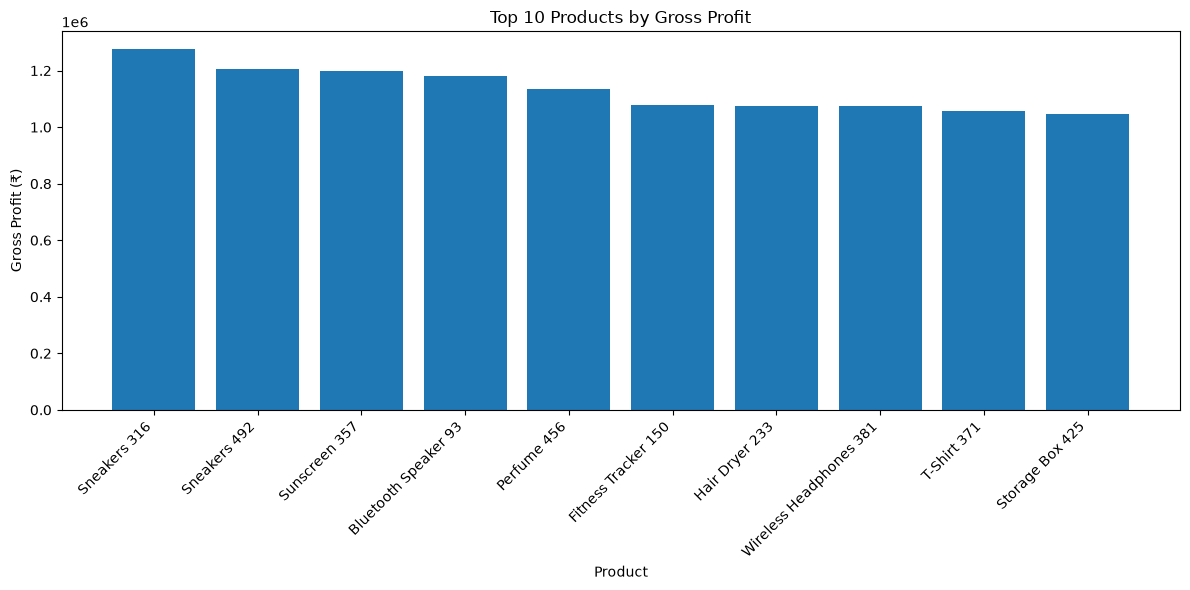

In [10]:
import matplotlib.pyplot as plt

top_10_profit = (
    product_summary
    .sort_values("Total_Gross_Profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_profit["product_name"],
    top_10_profit["Total_Gross_Profit"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Products by Gross Profit")

plt.xlabel("Product")

plt.ylabel("Gross Profit (₹)")

plt.tight_layout()

plt.show()

In [11]:
# Calculate median values
median_revenue = product_summary["Total_Revenue"].median()
median_profit = product_summary["Total_Gross_Profit"].median()


# Create product performance segmentation
def product_performance(row):

    if (
        row["Total_Revenue"] >= median_revenue
        and row["Total_Gross_Profit"] >= median_profit
    ):
        return "Star Products"

    elif (
        row["Total_Revenue"] >= median_revenue
        and row["Total_Gross_Profit"] < median_profit
    ):
        return "High Revenue Low Profit"

    elif (
        row["Total_Revenue"] < median_revenue
        and row["Total_Gross_Profit"] >= median_profit
    ):
        return "Growth Opportunities"

    else:
        return "Underperforming Products"


product_summary["Product_Performance"] = product_summary.apply(
    product_performance,
    axis=1
)

print("PRODUCT PERFORMANCE SEGMENTATION COMPLETED!")

product_summary.head()

PRODUCT PERFORMANCE SEGMENTATION COMPLETED!


,product_id,product_name,category,Total_Quantity,Total_Revenue,Total_Cost,Total_Gross_Profit,Total_Discount,Total_Orders,Profit_Margin_%,Product_Performance
315,P1315,Sneakers 316,Fashion,364,2.671823e+06,1396729.88,1.275093e+06,183560.3640,144,47.723714,Star Products
356,P1356,Sunscreen 357,Beauty,360,2.456967e+06,1258318.80,1.198648e+06,150278.7625,147,48.785691,Star Products
491,P1491,Sneakers 492,Fashion,322,2.444263e+06,1237809.86,1.206453e+06,160146.9540,136,49.358567,Star Products
92,P1092,Bluetooth Speaker 93,Electronics,316,2.439348e+06,1256912.12,1.182436e+06,149080.3860,125,48.473446,Star Products
424,P1424,Storage Box 425,Home & Kitchen,341,2.350453e+06,1302255.13,1.048198e+06,157775.6895,136,44.595573,Star Products


In [12]:
performance_summary = (
    product_summary["Product_Performance"]
    .value_counts()
)

print("PRODUCT PERFORMANCE DISTRIBUTION")
print("=" * 50)

print(performance_summary)

PRODUCT PERFORMANCE DISTRIBUTION
Product_Performance
Star Products               209
Underperforming Products    209
High Revenue Low Profit      41
Growth Opportunities         41
Name: count, dtype: int64


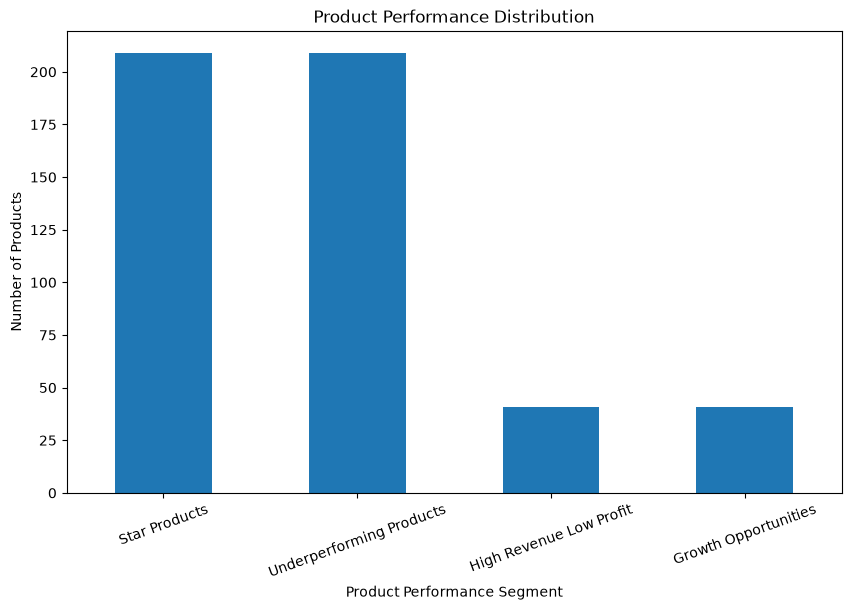

In [13]:
plt.figure(figsize=(10, 6))

performance_summary.plot(
    kind="bar"
)

plt.title("Product Performance Distribution")
plt.xlabel("Product Performance Segment")
plt.ylabel("Number of Products")

plt.xticks(rotation=20)

plt.show()

In [14]:
print("PRODUCT PERFORMANCE BUSINESS INSIGHTS")
print("=" * 60)

total_products = len(product_summary)

star_count = (
    product_summary["Product_Performance"]
    == "Star Products"
).sum()

underperforming_count = (
    product_summary["Product_Performance"]
    == "Underperforming Products"
).sum()

high_revenue_low_profit_count = (
    product_summary["Product_Performance"]
    == "High Revenue Low Profit"
).sum()

growth_count = (
    product_summary["Product_Performance"]
    == "Growth Opportunities"
).sum()

print(f"Total Products: {total_products}")
print(f"Star Products: {star_count}")
print(f"Underperforming Products: {underperforming_count}")
print(f"High Revenue Low Profit Products: {high_revenue_low_profit_count}")
print(f"Growth Opportunities: {growth_count}")

PRODUCT PERFORMANCE BUSINESS INSIGHTS
Total Products: 500
Star Products: 209
Underperforming Products: 209
High Revenue Low Profit Products: 41
Growth Opportunities: 41


## Key Business Insights

### 1. Star Products
The business has 209 Star Products that generate strong revenue and high gross profit.
These products should receive higher inventory priority and marketing investment.

### 2. Underperforming Products
There are 209 Underperforming Products.
The company should analyze whether these products suffer from low demand, poor pricing, excessive discounts, or weak marketing.

### 3. High Revenue but Low Profit
41 products generate strong revenue but have low profit margins.
The company should review product cost, pricing strategy, supplier contracts, and discount policies.

### 4. Growth Opportunities
41 products have the potential to become stronger performers.
Targeted promotions and improved visibility may help increase their sales and profitability.

### 5. Category Performance
Fashion and Home & Kitchen generate the highest overall revenue, while Fashion has the strongest gross profit performance.
The company should prioritize high-performing categories while improving margins in weaker areas.